# Shark Tank Pitch Event - Evaluation Pipeline
Pipeline para procesar data de evaluación entre pares.

In [1]:
import pandas as pd
import plotly.express as px
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import numpy as np

nltk.download('stopwords', quiet=True)
spanish_stopwords = set(stopwords.words('spanish'))

## 1. Data Loading
Cargamos el CSV. Si se usa Google Sheets publicado como CSV, reemplazar la ruta.

In [2]:
# Conexión local al CSV generado
df = pd.read_csv("mock_shark_tank.csv")
df.head()

,Timestamp,Student ID,Which team are you in?,Architecture [Team 1],Architecture [Team 2],Architecture [Team 3],Architecture [Team 4],Creativity [Team 1],Creativity [Team 2],Creativity [Team 3],Creativity [Team 4],Pitch [Team 1],Pitch [Team 2],Pitch [Team 3],Pitch [Team 4],Investment [Team 1],Investment [Team 2],Investment [Team 3],Investment [Team 4],Shark Justification
0,2026-05-06 19:000:00,10000,Team 4,3rd Place,3rd Place,3rd Place,3rd Place,NaN,NaN,1st Place,3rd Place,3rd Place,NaN,3rd Place,2nd Place,1st Place,1st Place,NaN,2nd Place,Es un pipeline de datos muy creativo y eficien...
1,2026-05-06 19:001:00,10001,Team 2,NaN,NaN,1st Place,3rd Place,3rd Place,1st Place,2nd Place,NaN,3rd Place,3rd Place,NaN,1st Place,3rd Place,1st Place,3rd Place,1st Place,"Sin duda, este es el mejor caso de uso para el..."
2,2026-05-06 19:002:00,10002,Team 1,NaN,3rd Place,2nd Place,NaN,1st Place,2nd Place,1st Place,2nd Place,3rd Place,2nd Place,2nd Place,2nd Place,NaN,1st Place,2nd Place,3rd Place,Es un pipeline de datos muy creativo y eficien...
3,2026-05-06 19:003:00,10003,Team 2,3rd Place,NaN,3rd Place,3rd Place,3rd Place,1st Place,1st Place,2nd Place,NaN,1st Place,2nd Place,1st Place,NaN,1st Place,1st Place,2nd Place,"El prompt de Gemma fue impecable, generó respu..."
4,2026-05-06 19:004:00,10004,Team 3,1st Place,2nd Place,3rd Place,NaN,3rd Place,3rd Place,3rd Place,3rd Place,NaN,3rd Place,NaN,1st Place,NaN,3rd Place,1st Place,NaN,"Sin duda, este es el mejor caso de uso para el..."


## 2. Business Logic & Point System
- 1st: 3pts, 2nd: 2pts, 3rd: 1pt.
- Self-vote exclusion.
- Shark Override (ID 3120523).

In [3]:
point_map = {"1st Place": 3, "2nd Place": 2, "3rd Place": 1}
teams = ["Team 1", "Team 2", "Team 3", "Team 4"]
metrics = ["Architecture", "Creativity", "Pitch", "Investment"]

df.fillna("None", inplace=True)

for m in metrics:
    for t in teams:
        col_name = f"{m} [{t}]"
        df[col_name + "_pts"] = df[col_name].map(point_map).fillna(0)

In [4]:
SHARK_ID = "3120523"
SHARK_MULTIPLIER = 3

for index, row in df.iterrows():
    student_id = str(row["Student ID"])
    voter_team = row["Which team are you in?"]
    
    is_shark = (student_id == SHARK_ID)
    multiplier = SHARK_MULTIPLIER if is_shark else 1
    
    for m in metrics:
        for t in teams:
            col_name_pts = f"{m} [{t}]_pts"
            
            # Exclusion logic: If not shark, and voter team is the target team, 0 points
            if not is_shark and voter_team == t:
                df.at[index, col_name_pts] = 0
            else:
                df.at[index, col_name_pts] = df.at[index, col_name_pts] * multiplier

## 3. Aggregation & Weights
- Architecture (40%)
- Creativity (40%)
- Pitch (20%)

*(Nota: Los puntajes acumulados aquí ya incluyen el Override del Shark (ID 3120523), cuyos puntos fueron multiplicados x3 en la sección anterior).*

In [5]:
WEIGHTS = {
    "Architecture": 0.40,
    "Creativity": 0.40,
    "Pitch": 0.20
}

team_scores = []

for t in teams:
    arch_total = df[f"Architecture [{t}]_pts"].sum() * WEIGHTS["Architecture"]
    crea_total = df[f"Creativity [{t}]_pts"].sum() * WEIGHTS["Creativity"]
    pitch_total = df[f"Pitch [{t}]_pts"].sum() * WEIGHTS["Pitch"]
    inv_total = df[f"Investment [{t}]_pts"].sum()
    
    team_scores.append({
        "Team": t,
        "Architecture": arch_total,
        "Creativity": crea_total,
        "Pitch": pitch_total,
        "Total Weighted Score": arch_total + crea_total + pitch_total,
        "Investment": inv_total
    })

df_scores = pd.DataFrame(team_scores)
df_scores

,Team,Architecture,Creativity,Pitch,Total Weighted Score,Investment
0,Team 1,12.0,11.2,5.0,28.2,31.0
1,Team 2,11.6,10.0,4.4,26.0,29.0
2,Team 3,13.2,15.6,6.2,35.0,33.0
3,Team 4,6.8,10.0,5.6,22.4,27.0


## 4. Visualizations

In [6]:
df_melted = df_scores.melt(id_vars=["Team", "Total Weighted Score", "Investment"], 
                           value_vars=["Architecture", "Creativity", "Pitch"],
                           var_name="Category", value_name="Weighted Points")

fig1 = px.bar(df_melted, x="Team", y="Weighted Points", color="Category", 
             barmode="group", title="Breakdown of Points per Team (Weighted)",
             text_auto='.2f', color_discrete_sequence=["#1A4B84", "#4285F4", "#90CAFA"])
fig1.show()

In [7]:
fig2 = px.bar(df_scores, x="Team", y="Investment", 
             title="Total Investment Capital per Team", color="Team", text_auto=True, color_discrete_sequence=["#1A4B84", "#4285F4", "#90CAFA", "#E3F2FD"])
fig2.show()

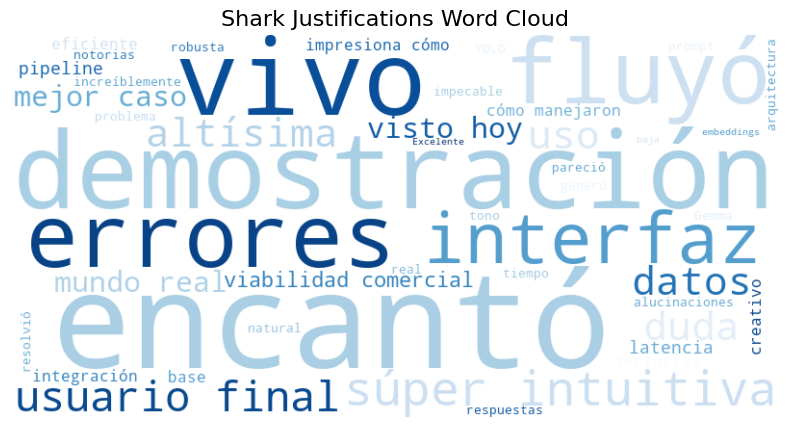

In [8]:
justifications = " ".join(df["Shark Justification"].astype(str).tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      stopwords=spanish_stopwords, colormap='Blues').generate(justifications)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Shark Justifications Word Cloud", fontsize=16)
plt.show()

## 5. Calificación Final (The Shark Award)
**Regla de Negocio:**
- El equipo con mayor capital de inversión se lleva el **100 cerrado** (Ganador del Shark Tank).
- El resto de los equipos reciben una calificación topada a **90**, calculada proporcionalmente a su *Total Weighted Score* (Evaluación de Pares).
- Se aplica una curva ajustada donde el piso mínimo es **80** y el equipo con la calificación más alta (excluyendo al ganador) alcanza exactamente el **90**.

In [11]:
# 1. Identificar al Ganador Absoluto (Max Investment)
winner_team = df_scores.loc[df_scores['Investment'].idxmax()]['Team']

# 2. Filtrar a los no ganadores para calcular una curva justa y estricta
df_others = df_scores[df_scores['Team'] != winner_team]

# Floor de 80, techo de 90 para el resto
max_score = df_others['Total Weighted Score'].max()
min_score = df_others['Total Weighted Score'].min()

final_grades = []

for index, row in df_scores.iterrows():
    team = row['Team']
    
    if team == winner_team:
        grade = 100.0
        status = "🦈 Ganador (100)"
    else:
        # Normalización Min-Max entre 80 y 90
        # Si todos los perdedores tienen el mismo score
        if max_score == min_score:
            grade = 85.0
        else:
            normalized = (row['Total Weighted Score'] - min_score) / (max_score - min_score)
            grade = 80 + (normalized * 10)
            
        status = "Aprobado"
        
    final_grades.append({
        "Team": team,
        "Total Weighted Score": row['Total Weighted Score'],
        "Investment": row['Investment'],
        "Final Grade": round(grade, 1),
        "Status": status
    })

df_final = pd.DataFrame(final_grades).sort_values(by="Final Grade", ascending=False)
df_final

,Team,Total Weighted Score,Investment,Final Grade,Status
2,Team 3,35.0,33.0,100.0,🦈 Ganador (100)
0,Team 1,28.2,31.0,90.0,Aprobado
1,Team 2,26.0,29.0,86.2,Aprobado
3,Team 4,22.4,27.0,80.0,Aprobado


In [12]:
fig3 = px.bar(df_final, x="Team", y="Final Grade", color="Status",
             title="Calificaciones Finales", text_auto=True,
             color_discrete_map={"🦈 Ganador (100)": "#FFD700", "Aprobado": "#4285F4"})
fig3.update_yaxes(range=[0, 105])
fig3.show()